Now that I have selected the templates I will find the thresholds.

In [1]:
from pathlib import Path
from calibration_calcs import compute_template_dtw_costs, compute_template_background_dtw_costs, compute_roc_curve, find_threshold_youden_from_roc, compute_auc, plot_roc_curve, plot_dtw_scatter, save_threshold

DATA_29 = Path(r"C:\Users\HP\Desktop\Skripsie data\29")
RESULTS_29 = DATA_29 / "template_selections"
RESULTS_29.mkdir(exist_ok=True)

single-tone dtws #10

In [ ]:
#returns all the costs for the templates as well as the pairs of templates compared for each cost
call_costs, call_pairs = compute_template_dtw_costs(
    RESULTS_29 / "20230429_Templates_20230429_102841_single_tone_templates.json",
    n_templates=10
)

In [ ]:
#returns the costs for templates vs background segemnts as well as the pairs
call_bg_costs, call_bg_pairs = compute_template_background_dtw_costs(
    RESULTS_29 / "20230429_Templates_20230429_102841_single_tone_templates.json",
    RESULTS_29 / "20230429_Background_20230429_102841_background.json",
    n_templates=10,
    n_background=5
)

Threshold: 0.1629 (J = 0.8200)


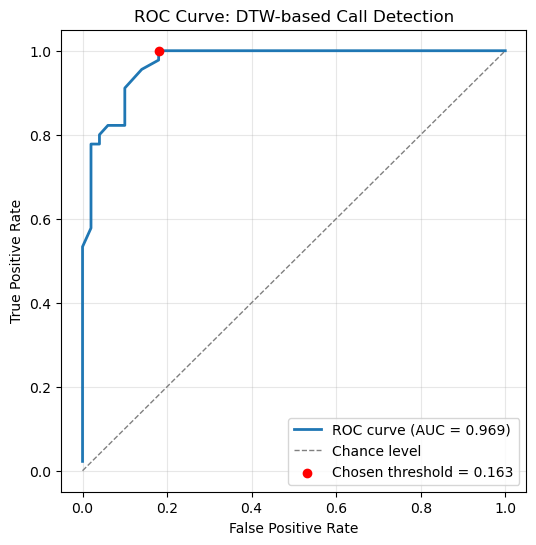

In [ ]:
#returns false positive and true positive rates as well as all calculated thresholds
fpr, tpr, thresholds = compute_roc_curve(call_costs, call_bg_costs)

#returns threshold and j_stat of the point that maximises the j_stat
threshold, j_stat = find_threshold_youden_from_roc(fpr, tpr, thresholds)

print(f"Threshold: {threshold:.4f} (J = {j_stat:.4f})") #print threshold and j_stat

#returns area under ROC curve
auc = compute_auc(fpr, tpr)

#plots TPR and FPR as well as threshold
plot_roc_curve(call_costs, call_bg_costs, best_threshold=threshold);

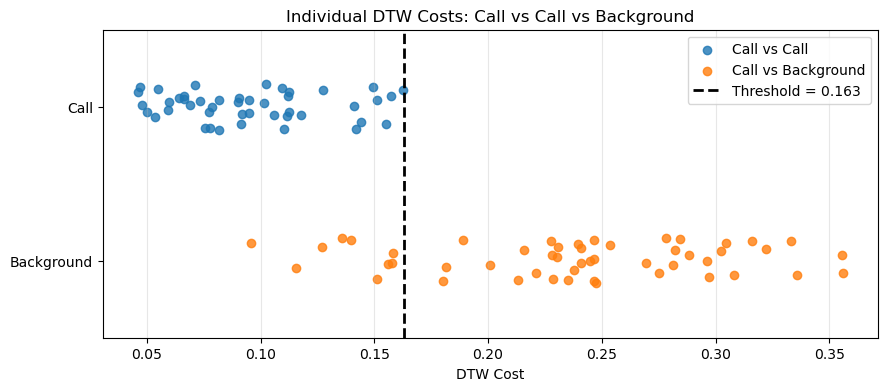

In [ ]:

#Plot every individual DTW cost as a point, split into two rows (call-vs-call and call-vs-background)
plot_dtw_scatter(call_costs, call_bg_costs, threshold=threshold)

In [ ]:
#auc = compute_auc(fpr, tpr)
#save threshold to .json file
save_threshold(
    threshold, j_stat, auc,
    call_type="single_tone",
    file_label="20230429_Templates",
    results_dir=RESULTS_29,
    n_templates=10,
    n_background=5,
);

Saved threshold for 'single_tone' (20230429_Templates) to 20230429_Templates_single_tone_threshold.json: threshold=0.1629, J=0.8200, AUC=0.9689


{'call_type': 'single_tone',
 'file_label': '20230429_Templates',
 'threshold': 0.16292170638658898,
 'youden_j': 0.8200000000000001,
 'auc': 0.9688888888888889,
 'n_templates': 10,
 'n_background': 5}

multi-tone dtws #10

In [9]:
call_costs, call_pairs = compute_template_dtw_costs(
    RESULTS_29 / "20230429_Templates_20230429_102841_multi_tone_templates.json",
    n_templates=10
)

In [10]:
call_bg_costs, call_bg_pairs = compute_template_background_dtw_costs(
    RESULTS_29 / "20230429_Templates_20230429_102841_multi_tone_templates.json",
    RESULTS_29 / "20230429_Background_20230429_102841_background.json",
    n_templates=10,
    n_background=5
)

Threshold: 0.1751 (J = 0.6244)


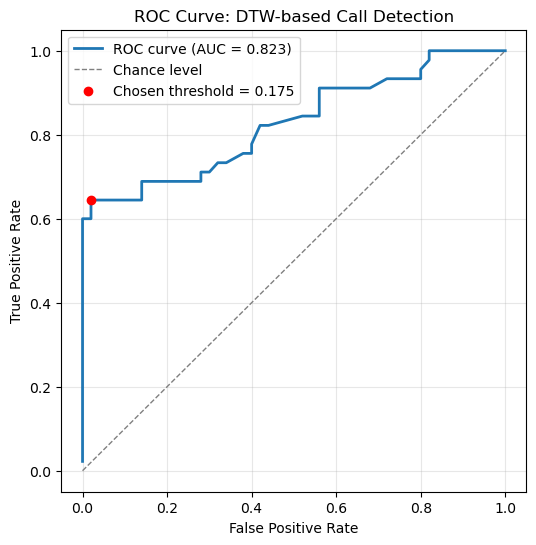

In [11]:
fpr, tpr, thresholds = compute_roc_curve(call_costs, call_bg_costs)
threshold, j_stat = find_threshold_youden_from_roc(fpr, tpr, thresholds)

print(f"Threshold: {threshold:.4f} (J = {j_stat:.4f})")

auc = compute_auc(fpr, tpr)
plot_roc_curve(call_costs, call_bg_costs, best_threshold=threshold);

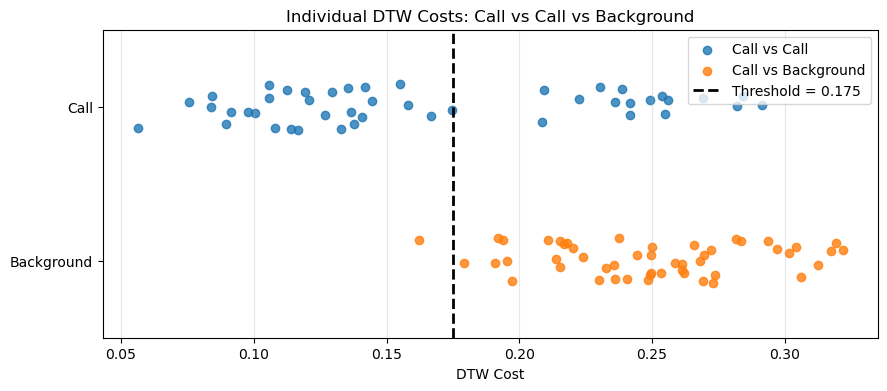

In [12]:
plot_dtw_scatter(call_costs, call_bg_costs, threshold=threshold)

In [ ]:
#auc = compute_auc(fpr, tpr)

save_threshold(
    threshold, j_stat, auc,
    call_type="multi_tone",
    file_label="20230429_Templates",
    results_dir=RESULTS_29,
    n_templates=10,
    n_background=5,
);

Saved threshold for 'multi_tone' (20230429_Templates) to 20230429_Templates_multi_tone_threshold.json: threshold=0.1751, J=0.6244, AUC=0.8231


{'call_type': 'multi_tone',
 'file_label': '20230429_Templates',
 'threshold': 0.17513743191345682,
 'youden_j': 0.6244444444444445,
 'auc': 0.8231111111111111,
 'n_templates': 10,
 'n_background': 5}

burst-tonal dtws #10

In [14]:
call_costs, call_pairs = compute_template_dtw_costs(
    RESULTS_29 / "20230429_Templates_20230429_102841_burst_tonal_templates.json",
    n_templates=10
)

In [15]:
call_bg_costs, call_bg_pairs = compute_template_background_dtw_costs(
    RESULTS_29 / "20230429_Templates_20230429_102841_burst_tonal_templates.json",
    RESULTS_29 / "20230429_Background_20230429_102841_background.json",
    n_templates=10,
    n_background=5
)

Threshold: 0.1517 (J = 1.0000)


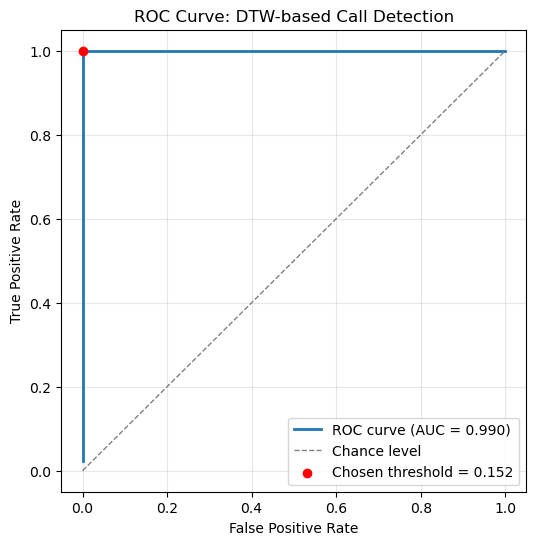

In [16]:
fpr, tpr, thresholds = compute_roc_curve(call_costs, call_bg_costs)
threshold, j_stat = find_threshold_youden_from_roc(fpr, tpr, thresholds)

print(f"Threshold: {threshold:.4f} (J = {j_stat:.4f})")

auc = compute_auc(fpr, tpr)
plot_roc_curve(call_costs, call_bg_costs, best_threshold=threshold);

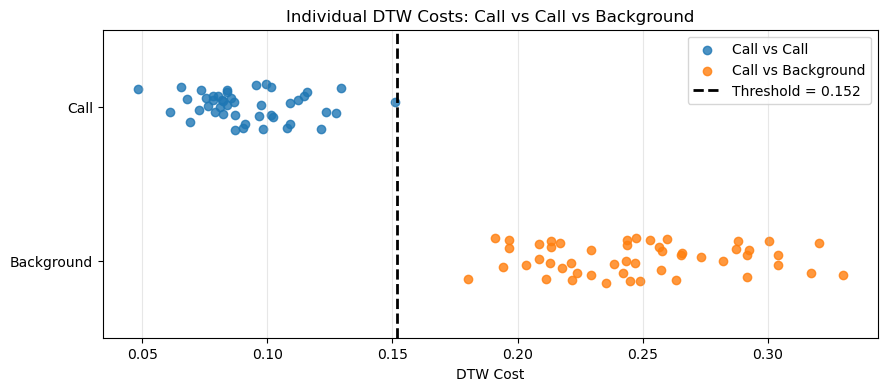

In [17]:
plot_dtw_scatter(call_costs, call_bg_costs, threshold=threshold)

In [ ]:
#auc = compute_auc(fpr, tpr)

save_threshold(
    threshold, j_stat, auc,
    call_type="burst_tonal",
    file_label="20230429_Templates",
    results_dir=RESULTS_29,
    n_templates=10,
    n_background=5,
);

Saved threshold for 'burst_tonal' (20230429_Templates) to 20230429_Templates_burst_tonal_threshold.json: threshold=0.1517, J=1.0000, AUC=0.9902


{'call_type': 'burst_tonal',
 'file_label': '20230429_Templates',
 'threshold': 0.15166169445617353,
 'youden_j': 1.0,
 'auc': 0.9902222222222222,
 'n_templates': 10,
 'n_background': 5}